In [1]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Compilación
!g++ -O3 -march=native -o pcap2bin pcap2bin.cpp
!g++ -O3 -march=native -o exact_hh exact_hh.cpp
!g++ -O3 -march=native -o sliding_window_estimator sliding_window_estimator.cpp
print("Compilación completada.")

Compilación completada.


In [6]:
# Descarga y conversión
!curl -O https://mawi.wide.ad.jp/mawi/samplepoint-F/2018/201812031400.pcap.gz

# Extraer y convertir a binario
!zcat 201812031400.pcap.gz | ./pcap2bin > traza.bin
print("Traza binaria 'traza.bin' generada exitosamente.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2976M  100 2976M    0     0  4810k      0  0:10:33  0:10:33 --:--:-- 6099k   0     0  5437k      0  0:09:20  0:01:06  0:08:14 6110k    0  4024k      0  0:12:37  0:03:17  0:09:20 2132k3948k      0  0:12:51  0:03:30  0:09:21 3289k 0     0  3972k      0  0:12:47  0:04:08  0:08:39 5840k  77 2314M    0     0  4777k      0  0:10:37  0:08:16  0:02:21  332k
pcap: linktype=1 
----------------------------------------------------------
frames leídos      : 132462957
registros escritos : 123383971  (2961.2 MB)
  IPv4             : 123383971
  IPv6             : 9078984 (descartados)
  no-IP descartados: 2
  truncados        : 0
  fragmentos !=0   : 64189  (sin puertos)
  con VLAN         : 0
fuera de orden     : 0
bytes en el cable  : 113562155437
duración           : 899.955314 s
tasa media         : 137100 pkt/s, 1.009 Gbps
------------

In [ ]:
# Obtener Ground Truth y Seleccionar HH

# Extraer el comportamiento global de las ventanas y el Top-K
print("Generando ground truth de ventanas y Top-K...")
subprocess.run([
    "./exact_hh", "traza.bin", "--key", "src", "--weight", "pkts", 
    "-W", "60", "--delta", "10", "--phi", "0.01", 
    "--topk", "20", "--out-windows", "win_W60.csv", "--out-topk", "topk_W60.csv"
], check=True)

# Seleccionar automáticamente el mayor Heavy Hitter real
df_topk = pd.read_csv("topk_W60.csv")
target_ip = df_topk['key'].iloc[0]
print(f"Heavy Hitter seleccionado automáticamente: {target_ip}")

# Generar la consulta exacta para esta IP específica
print(f"Generando consulta exacta para {target_ip}...")
subprocess.run([
    "./exact_hh", "traza.bin", "--key", "src", 
    "-W", "60", "--delta", "10", "--phi", "0.01", 
    "--query", target_ip, "--out-query", "exact_query.csv"
], check=True)
print("Ground truth de la consulta generado con éxito.")

Generando ground truth de ventanas y Top-K...
== ground truth por ventana ==
W = 60.000 s, delta = 10.000 s, phi = 0.01, k = 20
ventanas evaluadas   : 84
claves activas       : media 352987, máx 381193
memoria de la tabla  : 20.6 MB (máx, estimada)
VmHWM del proceso    : 2835.9 MB (incluye la traza mapeada)
Heavy Hitter seleccionado automáticamente: 203.83.117.211
Generando consulta exacta para 203.83.117.211...
== ground truth por ventana ==
W = 60.000 s, delta = 10.000 s, phi = 0.01, k = 20
ventanas evaluadas   : 84
claves activas       : media 352987, máx 381193
memoria de la tabla  : 20.6 MB (máx, estimada)
VmHWM del proceso    : 2836.0 MB (incluye la traza mapeada)
Ground truth de la consulta generado con éxito.


In [ ]:
# Ejecución de los Sketches
d = 5
widths = [256, 1024, 4096]
sketches = ["cm", "cs"]

memory_usage = {}

for sketch in sketches:
    for w in widths:
        # Calcular memoria: 7 matrices * d * w * 8 bytes
        bytes_mem = 7 * d * w * 8
        memory_usage[f"{sketch}_{w}"] = bytes_mem / 1024 # en KB
        
        output_csv = f"output_{sketch}_w{w}.csv"
        
        cmd = f"./sliding_window_estimator traza.bin {sketch} {d} {w} src {target_ip} > {output_csv}"
        print(f"Ejecutando: {cmd}")
        
        # subprocess.run reemplaza a os.system
        subprocess.run(cmd, shell=True, check=True)
        
print("Ejecuciones de sketches completadas.")

Ejecutando: ./sliding_window_estimator traza.bin cm 5 256 src 203.83.117.211 > output_cm_w256.csv
Ejecutando: ./sliding_window_estimator traza.bin cm 5 1024 src 203.83.117.211 > output_cm_w1024.csv
Ejecutando: ./sliding_window_estimator traza.bin cm 5 4096 src 203.83.117.211 > output_cm_w4096.csv
Ejecutando: ./sliding_window_estimator traza.bin cs 5 256 src 203.83.117.211 > output_cs_w256.csv
Ejecutando: ./sliding_window_estimator traza.bin cs 5 1024 src 203.83.117.211 > output_cs_w1024.csv
Ejecutando: ./sliding_window_estimator traza.bin cs 5 4096 src 203.83.117.211 > output_cs_w4096.csv
Ejecuciones de sketches completadas.


[CM w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 4931.52
[CM w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 985.24
[CM w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 126.45
[CS w=256] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 2396.08
[CS w=1024] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 528.21
[CS w=4096] Verificación Nj superada (Perfecta alineación).
   -> Error Absoluto Medio: 112.77


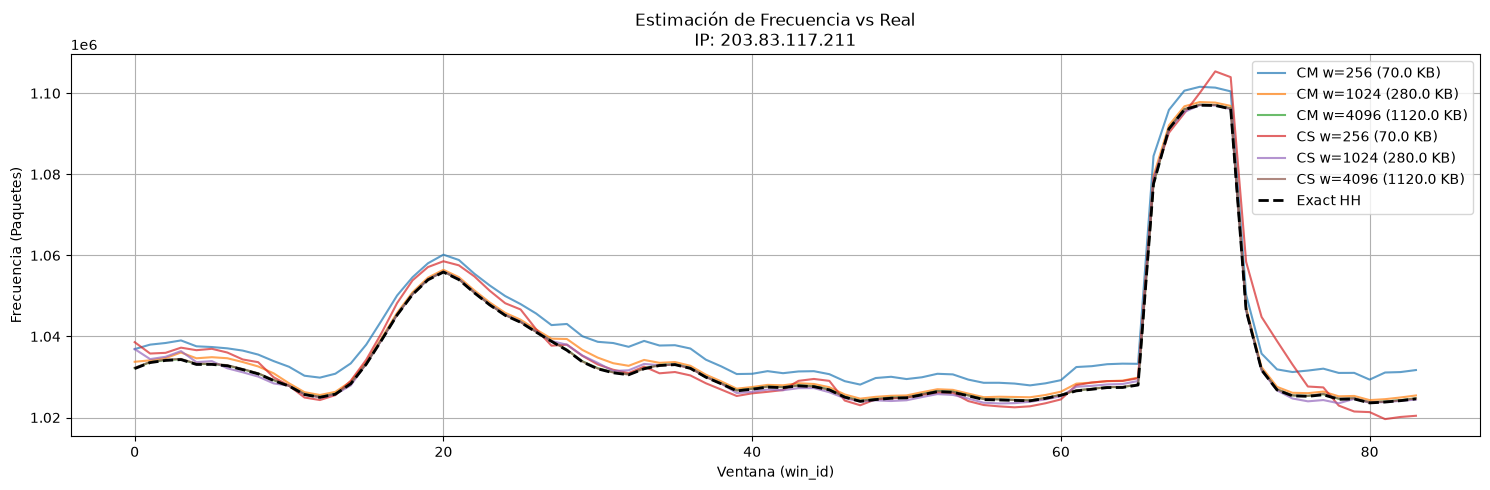

In [14]:
# Verificación Nj, Análisis y Gráficos

# Cargar los ground truths
df_exact_query = pd.read_csv("exact_query.csv")
df_exact_win = pd.read_csv("win_W60.csv")

# Filtrar y renombrar la consulta exacta
df_exact_query = df_exact_query[['tau_us', 'exact_f']].rename(columns={'exact_f': 'f_exact'})

# Para la verificación de N, filtramos win_W60 para tener solo tau_us y N
df_exact_win = df_exact_win[['tau_us', 'N']].rename(columns={'N': 'N_exact'})

fig, ax1 = plt.subplots(figsize=(15, 5))

for sketch in sketches:
    for w in widths:
        df_est = pd.read_csv(f"output_{sketch}_w{w}.csv")
        
        # Verificación del anillo Nj
        # Unimos las ventanas por el tiempo exacto de evaluación
        df_check = pd.merge(df_est, df_exact_win, on='tau_us', suffixes=('_est', '_exact'))
        
        # 'N' es de C++, 'N_exact' viene de win_W60.csv
        if not (df_check['N'] == df_check['N_exact']).all():
            raise AssertionError(f"Desalineación en {sketch} w={w}. Los contadores Nj no coinciden con exact_hh.")
        print(f"[{sketch.upper()} w={w}] Verificación Nj superada (Perfecta alineación).")

        # Unir estimaciones con la frecuencia real de la IP objetivo
        df_merged = pd.merge(df_est, df_exact_query, on='tau_us', how='inner')
        
        # Calcular Errores
        df_merged['abs_err'] = np.abs(df_merged['f_est'] - df_merged['f_exact'])
        df_merged['rel_err'] = df_merged['abs_err'] / df_merged['f_exact'].replace(0, 1)
        
        mean_abs = df_merged['abs_err'].mean()
        label = f"{sketch.upper()} w={w} ({memory_usage[f'{sketch}_{w}']:.1f} KB)"
        print(f"   -> Error Absoluto Medio: {mean_abs:.2f}")
        
        # Graficar en el Plot 1
        ax1.plot(df_merged['win'], df_merged['f_est'], label=label, alpha=0.7)

# Graficar la línea base del ground truth
ax1.plot(df_merged['win'], df_merged['f_exact'], 'k--', linewidth=2, label='Exact HH')

ax1.set_title(f"Estimación de Frecuencia vs Real\nIP: {target_ip}")
ax1.set_xlabel("Ventana (win_id)")
ax1.set_ylabel("Frecuencia (Paquetes)")
ax1.legend()
ax1.grid(True)

plt.tight_layout()
plt.show()